# Подготовка

In [54]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from wordcloud import WordCloud

In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
!python -m spacy download ru_core_news_sm

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/v.makshanchikov/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/v.makshanchikov/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/v.makshanchikov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 2.7 MB/s  0:00:06m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')


In [17]:
files = ["soltwine1.txt", "soltwine2.txt", "soltwine3.txt"]

texts = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        texts.append(f.read())

texts

['Мне не хочется знать о том, как у тебя дела\nНо ты выглядишь так привлекательно\nДля тебя всё сегодня бесплатно\nЕдь ко мне сразу без платья\nМог бы соврать, но я не столько хочу тебя\nСколько просто ищу тепла\nЯ бы мог написать другой\nТы просто была под рукой\nПриезжай уже, ты такая же\nНам обоим плевать, что у нас в душе\nТы сама намекала на это же\nПозвони мне, как будешь на этаже\nЕсли будет паршиво, мы снова друг другу напишем и поможем\nПереспим, а потом я скажу, как тоскую по бывшей, ты же тоже?\nНам покажется, будто сейчас мы становимся ближе, не похоже\nПереспим, а потом я скажу, как тоскую по бывшей, ты же тоже? Ты же тоже?\nЕсли ты едешь ко мне не ищи во мне принца\nНа белом коне или рыцаря\nВ планах на вечер напиться\nЧтоб усыпить свои взгляды и принципы\nТак веселей будет падать ко дну\nВедь ничего не стоит на кону\nИ мы ничего не должны никому\nНо откуда я чувствую стыд и вину?\nБезобидная шалость:\nПо бокалу — и можем раздеться\nНо в груди заболело и сжалось\nЧто-то в

# Часть 1

In [18]:
def preprocess(text):
    # Нижний регистр
    text = text.lower()
    
    # Удаление всего кроме букв
    text = re.sub(r"[^а-яё\s]", " ", text)
    
    # Обработка через spaCy
    doc = nlp(text)
    
    tokens = []
    for token in doc:
        # Убираем стоп-слова, пунктуацию, пробелы и короткие слова
        if (
            not token.is_stop
            and not token.is_punct
            and not token.is_space
            and len(token.lemma_) > 2
        ):
            tokens.append(token.lemma_)
    
    return " ".join(tokens)

In [19]:
for i, text in enumerate(texts):
    print(f"Песня {i+1}: {len(text.split())} слов до очистки")

nlp = spacy.load("ru_core_news_sm")
cleaned_texts = [preprocess(text) for text in texts]

# Проверка размера текстов
for i, text in enumerate(cleaned_texts):
    print(f"Песня {i+1}: {len(text.split())} слов после очистки")

cleaned_texts

Песня 1: 258 слов до очистки
Песня 2: 366 слов до очистки
Песня 3: 231 слов до очистки
Песня 1: 97 слов после очистки
Песня 2: 157 слов после очистки
Песня 3: 107 слов после очистки


['хотеться знать дело выглядеть привлекательно сегодня бесплатно едь платье соврать столько искать тепло написать рука приезжай оба плевать душа намекать позвонить этаж паршиво друг другу написать поможем переспать сказать тоскую бывший показаться становиться близкий похожий переспать сказать тоскую бывший ехать искать принц белый конь рыцарь план вечер напиться усыпить взгляд принцип веселей падать дно стоить кон чувствовать стыд вина безобидный шалость бокал раздеться грудь заболеть сжалось область сердце страсть жалость загадка становиться гадко недочёт идеальный план недостаточно пьяный пойти добавка паршиво друг другу написать поможем переспать сказать тоскую бывший показаться становиться близкий похожий переспать сказать тоскую бывший',
 'молодец бывший отличный вкус школа красный аттестат столичный вуз удивиться готовиться детство думать легко влюблюсь проходить бюджет ходить послушно пара сто год поить копейка барин местный уверенный стать известный постоянно пить писать песня 

- Объём текстов сократился примерно на 55–65%.
- Это означает, что:
- стоп-слова удалены корректно,
- лемматизация работает,
- шум (частицы, союзы, повторы) устранён.

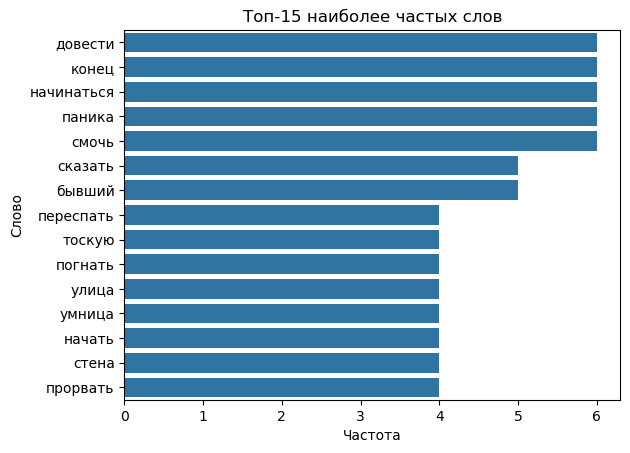

In [20]:
# Объединяем тексты в один корпус
all_tokens = " ".join(cleaned_texts).split()

word_counts = Counter(all_tokens)

# Топ-15 слов
top_words = word_counts.most_common(15)

df_top = pd.DataFrame(top_words, columns=["Слово", "Частота"])

plt.figure()
sns.barplot(data=df_top, x="Частота", y="Слово")
plt.title("Топ-15 наиболее частых слов")
plt.show()

Наиболее частые леммы:

- довести, конец, начинаться, паника, смочь — по 6 раз
- сказать, бывший — по 5 раз

Это говорит о:
- наличии сюжетной динамики ("начинаться", "конец")
- выраженной эмоциональной составляющей ("паника", "тоскую")
- повторяющейся рефлексии/взаимоотношениях ("бывший", "переспать")

Тексты явно эмоционально окрашены и построены вокруг конфликтных или драматических состояний.

In [21]:
# Преобразуем частоты в список
frequencies = list(word_counts.values())

# Базовая статистика
print("Количество уникальных слов:", len(word_counts))
print("Средняя частота:", np.mean(frequencies))
print("Медианная частота:", np.median(frequencies))
print("Максимальная частота:", np.max(frequencies))
print("Минимальная частота:", np.min(frequencies))

Количество уникальных слов: 240
Средняя частота: 1.5041666666666667
Медианная частота: 1.0
Максимальная частота: 6
Минимальная частота: 1


Корпус характеризуется высокой лексической разреженностью: медианная частота равна 1, что означает, что более половины слов встречаются однократно. Максимальная частота не превышает 6, что говорит об отсутствии выраженных доминирующих лексем.

## TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(cleaned_texts)

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=["Песня 1", "Песня 2", "Песня 3"]
)

tfidf_df

,аттестат,бар,барин,бежать,безмятежный,безобидный,белый,бережный,бесплатно,близкий,...,центральный,час,чердак,чертах,честно,чувствовать,шалость,школа,этаж,яма
Песня 1,0.00000,0.00000,0.00000,0.000000,0.000000,0.080165,0.080165,0.00000,0.080165,0.160331,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.080165,0.080165,0.00000,0.080165,0.00000
Песня 2,0.05539,0.05539,0.05539,0.000000,0.000000,0.000000,0.000000,0.05539,0.000000,0.000000,...,0.05539,0.05539,0.05539,0.05539,0.11078,0.000000,0.000000,0.05539,0.000000,0.05539
Песня 3,0.00000,0.00000,0.00000,0.181464,0.181464,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000


In [47]:
for i in range(3):
    print(f"\nТоп слов для Песни {i+1}:")
    print(tfidf_df.iloc[i].sort_values(ascending=False).head(5))


Топ слов для Песни 1:
тоскую         0.320661
переспать      0.320661
сказать        0.243871
бывший         0.243871
становиться    0.240496
Name: Песня 1, dtype: float64

Топ слов для Песни 2:
конец        0.332339
довести      0.332339
нравиться    0.221560
умница       0.221560
рандеву      0.221560
Name: Песня 2, dtype: float64

Топ слов для Песни 3:
паника        0.362928
смочь         0.362928
начинаться    0.362928
тревог        0.181464
клубок        0.181464
Name: Песня 3, dtype: float64


**Песня 1**
- тоскую, переспать, сказать, бывший, становиться

Доминирует тема отношений и эмоционального переживания. TF-IDF выделил более личные и контекстные слова.


**Песня 2**
- конец, довести, нравиться, умница, рандеву

Здесь появляется сюжетная завершённость ("конец", "довести"). Появляется слово "рандеву" — оно, вероятно, уникально для этой песни. TF-IDF подчёркивает нарративную структуру


**Песня 3**
- паника, смочь, начинаться, тревог, клубок

Чёткая эмоционально-тревожная окраска. Слова имеют психологический характер. TF-IDF изолировал эмоциональный контекст

## CountVectorizer

In [33]:
count_vectorizer = CountVectorizer()

count_matrix = count_vectorizer.fit_transform(cleaned_texts)

count_feature_names = count_vectorizer.get_feature_names_out()

count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_feature_names,
    index=["Песня 1", "Песня 2", "Песня 3"]
)

for i in range(3):
    print(f"\nТоп слов для Песни {i+1}:")
    print(count_df.iloc[i].sort_values(ascending=False).head(5))


Топ слов для Песни 1:
сказать        4
тоскую         4
бывший         4
переспать      4
становиться    3
Name: Песня 1, dtype: int64

Топ слов для Песни 2:
конец        6
довести      6
рандеву      4
стена        4
нравиться    4
Name: Песня 2, dtype: int64

Топ слов для Песни 3:
смочь         6
начинаться    6
паника        6
увидеть       3
издалёка      3
Name: Песня 3, dtype: int64


В песне 1 оба метода дают практически идентичный результат, потому что слова действительно уникальны и часто повторяются внутри одного документа. 

Во 2-ой песне TF-IDF слегка “переупорядочил” слова, снижая вес тех, что встречаются и в других песнях.

В 3-ей разница минимальна, потому что эти слова почти не встречаются в других документах — значит их IDF высокий. 

В данном корпусе из трёх песен различие между TF-IDF и CountVectorizer выражено умеренно. Это связано с тем, что:
- корпус небольшой,
- документы тематически различаются,
- пересечение лексики ограничено.

При большем корпусе TF-IDF показал бы более выраженное отличие.

## Word2Vec

In [35]:
# Токенизированные тексты
tokenized_texts = [text.split() for text in cleaned_texts]

# Обучаем модель Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

print("Размер словаря Word2Vec:", len(w2v_model.wv))

Размер словаря Word2Vec: 240


Словарь = 240 слов, совпадает с числом уникальных лемм

In [36]:
def document_vector(model, doc):
    vectors = []
    for word in doc:
        if word in model.wv:
            vectors.append(model.wv[word])
    return np.mean(vectors, axis=0)

w2v_doc_vectors = np.array([
    document_vector(w2v_model, doc)
    for doc in tokenized_texts
])

print("Размерность вектора документа:", w2v_doc_vectors.shape)

Размерность вектора документа: (3, 100)


Матрица документов = 3 × 100 (3 песни, embedding размерности 100).

In [38]:
w2v_similarity = cosine_similarity(w2v_doc_vectors)

w2v_sim_df = pd.DataFrame(
    w2v_similarity,
    index=["Песня 1", "Песня 2", "Песня 3"],
    columns=["Песня 1", "Песня 2", "Песня 3"]
)

w2v_sim_df

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.027004,-0.022150
Песня 2,0.027004,1.000000,0.036161
Песня 3,-0.022150,0.036161,1.000000


Все значения близки к 0. Есть даже слабая отрицательная корреляция. Документы практически семантически не похожи.

Word2Vec на малом корпусе работает нестабильно и плохо выявляет семантическую близость

## Doc2Vec

In [42]:
tagged_data = [
    TaggedDocument(words=text.split(), tags=[str(i)])
    for i, text in enumerate(cleaned_texts)
]

doc2vec_model = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=100,
    seed=42
)

doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(tagged_data, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

# Получаем векторы документов
doc2vec_vectors = np.array([
    doc2vec_model.dv[str(i)]
    for i in range(3)
])

print("Размерность Doc2Vec:", doc2vec_vectors.shape)

Размерность Doc2Vec: (3, 100)


In [43]:
doc2vec_similarity = cosine_similarity(doc2vec_vectors)

doc2vec_sim_df = pd.DataFrame(
    doc2vec_similarity,
    index=["Песня 1", "Песня 2", "Песня 3"],
    columns=["Песня 1", "Песня 2", "Песня 3"]
)

doc2vec_sim_df

,Песня 1,Песня 2,Песня 3
Песня 1,1.000000,0.991338,0.991277
Песня 2,0.991338,1.000000,0.984069
Песня 3,0.991277,0.984069,1.000000


Doc2Vec считает все документы почти идентичными, так как корпус состоит всего из 3 документов. Doc2Vec обучается предсказывать контекст документа. При таком маленьком корпусе модель:
- быстро переобучается,
- не формирует различающиеся векторы,
- "схлопывает" пространство.

## Выводы по части 1

**Результаты сравнения к нашему корпусу текстов**

| Метод | Учитывает частоту | Учитывает распределение | Учитывает семантику | Подходит для малого корпуса |
|---|---|---|---|---|
| CountVectorizer | ✅ | ❌ | ❌ | ✅ |
| TF-IDF | ✅ | ✅ | ❌ | ✅ |
| Word2Vec | ❌ | ❌ | ✅ | ❌ |
| Doc2Vec | ❌ | ❌ | ✅ | ❌ |

- Частотные методы (CountVectorizer и TF-IDF) продемонстрировали устойчивую работу на малом корпусе и позволили выделить тематически значимые лексемы. 
- TF-IDF оказался наиболее информативным методом, поскольку учитывает распределение слов между документами и снижает влияние общих лексем.
- Word2Vec и Doc2Vec продемонстрировали ограниченную применимость на малом корпусе: первый не выявил выраженной семантической структуры, второй показал признаки переобучения.
- Для задач анализа небольшого набора текстов предпочтительны статистические методы, тогда как нейросетевые embedding-модели требуют существенно большего объёма данных.

**Результаты сравнения по критерям**

*Сложность вычислений:*
| Метод | Сложность (обучение) | Сложность (инференс) | Комментарий |
|---|---|---|---|
| CountVectorizer | O(N·V) | O(V) | Простая матричная операция |
| TF-IDF | O(N·V) | O(V) | + расчёт IDF |
| Word2Vec | O(E·T·W) | O(D) | Итеративное обучение |
| Doc2Vec | O(E·T·W) | O(D) | Более тяжёлая версия Word2Vec |

Где:
N — документы
V — словарь
E — эпохи
T — токены
W — окно контекста
D — размерность вектора

TF-IDF и CountVectorizer значительно легче вычислительно.

*Качество представления*
| Метод | Различимость документов | Устойчивость на малых данных |
|---|---|---|
| CountVectorizer | Средняя | Высокая |
| TF-IDF | Высокая | Высокая |
| Word2Vec | Низкая | Низкая |
| Doc2Vec | Переобучение | Очень низкая |

*Интерпретируемость*
| Метод | Интерпретируемость |
|---|---|
| CountVectorizer | Очень высокая |
| TF-IDF | Высокая |
| Word2Vec | Низкая |
| Doc2Vec | Низкая |

**Итог:** Дял малого корпуса песен TF-IDF — оптимальный метод.



## Статистический анализ

### Топ-10 наиболее часто встречаемых слов

In [48]:
top_10_words = word_counts.most_common(10)

df_top_10 = pd.DataFrame(top_10_words, columns=["Слово", "Частота"])
df_top_10

,Слово,Частота
0,довести,6
1,конец,6
2,начинаться,6
3,паника,6
4,смочь,6
5,сказать,5
6,бывший,5
7,переспать,4
8,тоскую,4
9,погнать,4


Лексика отражает эмоционально-конфликтный характер текстов.

Частотное ядро строится вокруг:
- завершённости ("конец", "довести"),
- внутреннего напряжения ("паника"),
- личных отношений ("бывший", "переспать", "тоскую").

Максимальная частота остаётся умеренной (6), что подтверждает отсутствие сильной рефренной доминанты.

### Топ-10 наиболее часто встречаемых комбинаций слов

In [49]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2))
bigram_matrix = bigram_vectorizer.fit_transform(cleaned_texts)

bigram_counts = bigram_matrix.toarray().sum(axis=0)
bigram_features = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "Биграмма": bigram_features,
    "Частота": bigram_counts
})

bigram_df = bigram_df.sort_values(by="Частота", ascending=False).head(10)
bigram_df

,Биграмма,Частота
57,довести конец,6
119,начинаться паника,6
228,стена прорвать,4
162,погнать улица,4
124,нравиться довести,4
243,тоскую бывший,4
118,начать стена,4
251,умница начать,4
250,улица умница,4
213,сказать тоскую,4


Частотные сочетания подтверждают сюжетную структуру текстов. Повторяются устойчивые эмоциональные конструкции.

Видна тематическая сегментация:
- Песня 2 — "довести конец"
- Песня 3 — "начинаться паника"
- Песня 1 — "сказать тоскую", "тоскую бывший"

Биграммы дают более содержательную картину, чем униграммы.

### Облако слов корпуса песен

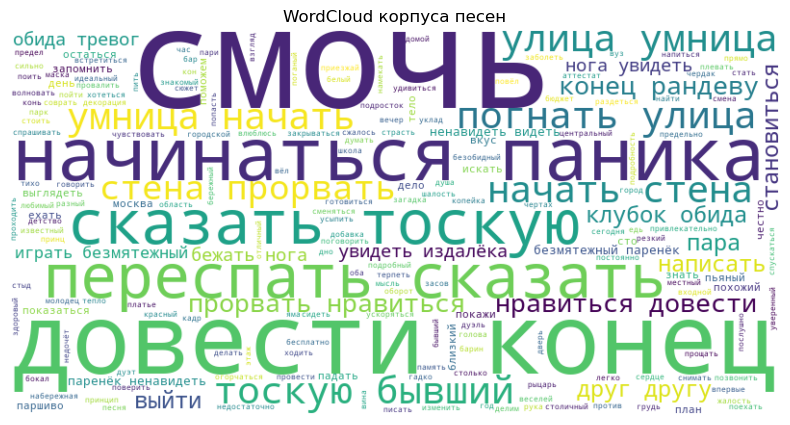

In [ ]:
text_for_cloud = " ".join(cleaned_texts)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate(text_for_cloud)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud корпуса песен")
plt.show()

WordCloud подтверждает результаты частотного анализа, но не даёт количественной строгости.

### t-SNE визуализация

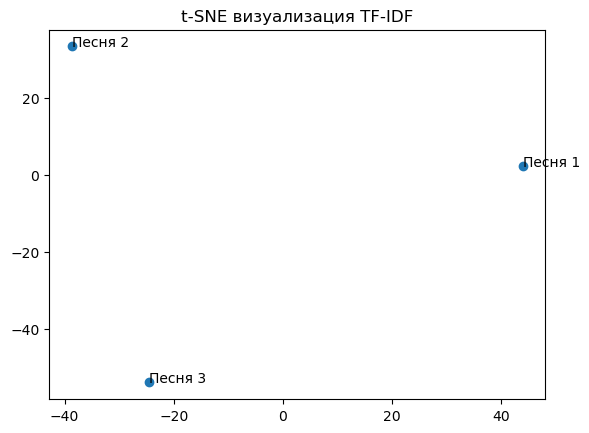

In [53]:
tsne = TSNE(n_components=2, random_state=42, perplexity=2)

tfidf_2d = tsne.fit_transform(tfidf_matrix.toarray())

plt.figure()
plt.scatter(tfidf_2d[:,0], tfidf_2d[:,1])

for i, label in enumerate(["Песня 1", "Песня 2", "Песня 3"]):
    plt.annotate(label, (tfidf_2d[i,0], tfidf_2d[i,1]))

plt.title("t-SNE визуализация TF-IDF")
plt.show()

TF-IDF формирует различимые векторные представления документов. Документы в пространстве признаков не перекрываются. Это означает сематическую различимость песен, а также корректность TF-IDF для малого корпуса.

# Часть 2